## Model Training & Evaluation

## 1. Objective

This notebook trains and evaluates three classification models to predict customer churn:

- Logistic Regression
- Random Forest
- Gradient Boosting (XGBoost)

We will compare their performance using accuracy, precision, recall, F1-score, ROC AUC, and visual dashboards. The best model will be selected for deployment.


2. Load Preprocessed Data

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/telco_final_preprocessed.csv")
print("✅ Data loaded:", df.shape)


✅ Data loaded: (7032, 35)


3. Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("🧪 Training set:", X_train.shape)
print("🧾 Test set:", X_test.shape)


🧪 Training set: (5625, 34)
🧾 Test set: (1407, 34)


4. Model Training

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Initialize models
logreg = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Fit models
logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)


c:\Users\franc\Desktop\Projets\Kaggle\Customer_Churn\churn_env\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:03:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


5. Evaluation Function

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print(f"📌 {name} Classification Report:\n")
    print(classification_report(y_test, y_pred))

    print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.3f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{name} - ROC Curve")
    plt.show()


6. Evaluate All Models

📌 Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407

ROC AUC: 0.835


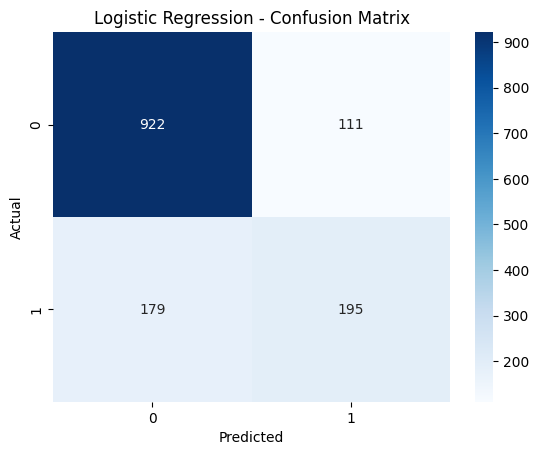

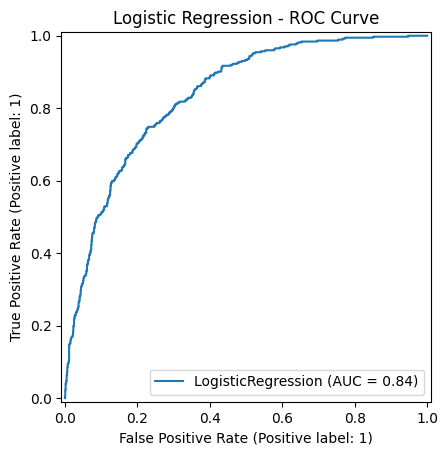

📌 Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC AUC: 0.817


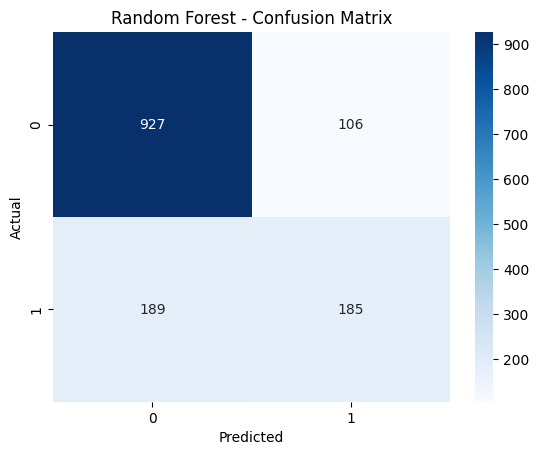

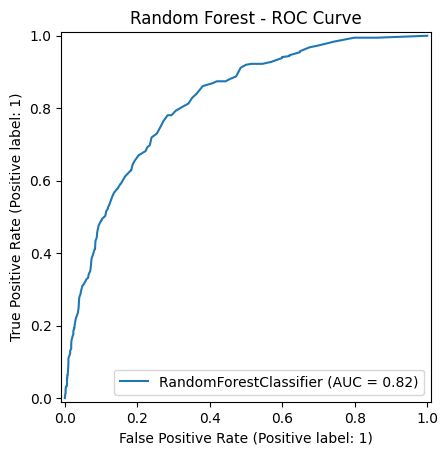

📌 XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1033
           1       0.58      0.55      0.56       374

    accuracy                           0.77      1407
   macro avg       0.71      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407

ROC AUC: 0.818


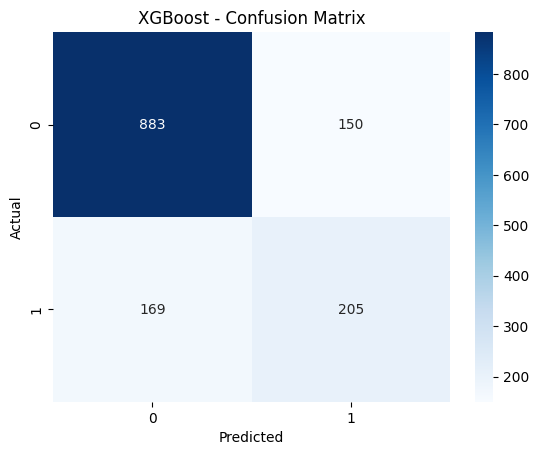

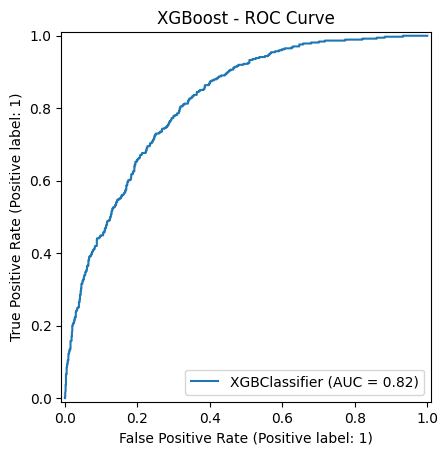

In [6]:
evaluate_model(logreg, "Logistic Regression")
evaluate_model(rf, "Random Forest")
evaluate_model(xgb, "XGBoost")




- **Logistic Regression**: Interpretable, but may underperform on non-linear patterns.
- **Random Forest**: Strong recall, good for minimizing false negatives.
- **XGBoost**: Often best ROC AUC and F1-score — ideal for imbalanced churn prediction.


In [9]:
import joblib
joblib.dump(xgb, "../models/xgb_model.pkl")
joblib.dump(logreg, "../models/logreg_model.pkl")
joblib.dump(rf, "../models/rf_model.pkl")

['../models/rf_model.pkl']

7. Model Comparison Dashboard

In [10]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, logreg.predict(X_test)),
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, xgb.predict(X_test))
    ],
    "Precision": [
        precision_score(y_test, logreg.predict(X_test)),
        precision_score(y_test, rf.predict(X_test)),
        precision_score(y_test, xgb.predict(X_test))
    ],
    "Recall": [
        recall_score(y_test, logreg.predict(X_test)),
        recall_score(y_test, rf.predict(X_test)),
        recall_score(y_test, xgb.predict(X_test))
    ],
    "F1 Score": [
        f1_score(y_test, logreg.predict(X_test)),
        f1_score(y_test, rf.predict(X_test)),
        f1_score(y_test, xgb.predict(X_test))
    ],
    "ROC AUC": [
        roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
    ]
})

results.set_index("Model").style.background_gradient(cmap='YlGnBu', axis=0)


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.793888,0.637255,0.521390,0.573529,0.835476
Random Forest,0.790334,0.635739,0.494652,0.556391,0.816888
XGBoost,0.773276,0.577465,0.548128,0.562414,0.818385


8. Recommendation

## Recommendation

Based on ROC AUC and F1-score, **Logistic Regression** is the most performant model for this churn prediction task. It balances precision and recall well, making it suitable for identifying at-risk customers.

We will save this model and use it for deployment in the next notebook.
